# 07 -- RAG-Augmented Hallucination Detection
## LLM Lie Detector | Phase 5

This notebook extends the base hallucination detector with a retrieval pipeline.
Given a question and an LLM-generated answer, the system first retrieves relevant
factual context from Wikipedia, then passes that context alongside the answer to
the detector. The goal is to measure whether grounded retrieval improves detection
accuracy over the fine-tuned model alone.

### Goals
- Build a Wikipedia retrieval pipeline using FAISS and sentence-transformers
- Run the original detector (System A) on a validation sample
- Run the RAG-augmented detector (System B) on the same sample
- Compare results: does retrieval improve F1, precision, and recall?

### Hypothesis
The base detector struggles on simple factual questions underrepresented
in TruthfulQA and HaluEval. Retrieval should ground those cases in
evidence and improve detection accuracy.

In [1]:
import os
os.environ["PYTHONUTF8"] = "1"

import torch
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
import faiss
import wikipediaapi

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print("All imports successful.")

CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU
All imports successful.


In [2]:
# Load the combined dataset and recreate the validation split
from sklearn.model_selection import train_test_split

df = pd.read_csv('../data/combined_dataset.csv')

_, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df['label']
)
val_df = val_df.reset_index(drop=True)

# Work with the entire sample of 1,592 to test the pipeline
sample_df = val_df.copy()

print(f"Full validation set: {len(val_df)} samples")
print(f"Working sample: {len(sample_df)} samples")
print(f"\nLabel distribution in sample:")
print(sample_df['label'].value_counts())

Full validation set: 1592 samples
Working sample: 1592 samples

Label distribution in sample:
label
1    833
0    759
Name: count, dtype: int64


In [3]:
import wikipediaapi
import wikipedia
import re

# Install wikipedia package if needed
# pip install wikipedia

wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='LLMDetector/1.0 (tamim.mirza@rwth-aachen.de)'
)

def retrieve_context(question: str, max_chars: int = 500) -> str:
    """
    Retrieve relevant Wikipedia context for a given question.
    
    Uses three strategies in order:
    1. Direct Wikipedia page lookup with cleaned question
    2. Wikipedia search API to find the best matching page
    3. Returns empty string if nothing found
    
    Args:
        question:  The question to retrieve context for.
        max_chars: Maximum characters to return from the article.
    
    Returns:
        Retrieved context string, or empty string if not found.
    """
    # Clean the question into a search term
    stopwords = [
        "what is", "what are", "what was", "what were",
        "who is", "who was", "who were",
        "where is", "where was", "where did", "where does",
        "when did", "when was", "when is",
        "how many", "how much", "how did", "how does",
        "why did", "why is", "why does",
        "which", "whose", "whom"
    ]
    
    cleaned = question.lower()
    for sw in stopwords:
        cleaned = cleaned.replace(sw, "")
    cleaned = re.sub(r'[^\w\s]', '', cleaned).strip().title()
    
    # Strategy 1: direct page lookup
    page = wiki.page(cleaned)
    if page.exists():
        return page.summary[:max_chars]
    
    # Strategy 2: Wikipedia search API
    try:
        search_results = wikipedia.search(question, results=1)
        if search_results:
            page = wiki.page(search_results[0])
            if page.exists():
                return page.summary[:max_chars]
    except Exception:
        pass
    
    return ""

# Test again
test_questions = [
    "Where did fortune cookies originate?",
    "What is the capital of France?",
    "Who invented the telephone?",
]

for q in test_questions:
    ctx = retrieve_context(q)
    print(f"Q: {q}")
    print(f"Context: {ctx[:200] if ctx else 'NOT FOUND'}")
    print("---")

Q: Where did fortune cookies originate?
Context: A fortune cookie is a crisp and sugary cookie wafer made from flour, sugar, vanilla, and sesame seed oil with a piece of paper inside, a "fortune", an aphorism, or a vague prophecy. The message inside
---
Q: What is the capital of France?
Context: A closed-ended question is any question for which a researcher provides research participants with options from which to choose a response. Closed-ended questions are sometimes phrased as a statement 
---
Q: Who invented the telephone?
Context: A telephone, commonly shortened to phone, is a telecommunications device that enables two or more users to conduct a conversation when they are too far apart to be easily heard directly. A telephone c
---


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login

# Login to HuggingFace
login(token=os.getenv("HF_TOKEN"))

model_id = "meta-llama/Llama-3.2-3B-Instruct"
adapter_id = "tamimmirza/llama-3.2-3b-hallucination-detector"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto"
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, adapter_id)
model.eval()

print(f"\nModel ready.")
print(f"VRAM used: {torch.cuda.memory_allocated(0) / 1e9:.1f} GB")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading tokenizer...
Loading base model...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loading LoRA adapter...


W0510 19:19:45.582000 26672 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels



Model ready.
VRAM used: 6.4 GB


In [5]:
def predict_system_a(question: str, answer: str) -> dict:
    """
    System A: Base fine-tuned detector with no retrieval.
    
    Takes a question and answer, runs them through the fine-tuned
    Llama model, and returns the verdict. This is the baseline
    system from Phase 2.
    
    Args:
        question: The original question.
        answer:   The LLM-generated answer to evaluate.
    
    Returns:
        dict with verdict (str) and system (str) keys.
    """
    prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()
    
    if "HALLUCINATED" in response:
        verdict = "HALLUCINATED"
    elif "TRUTHFUL" in response:
        verdict = "TRUTHFUL"
    else:
        verdict = "UNCERTAIN"
    
    return {"verdict": verdict, "system": "A", "context_used": None}


def predict_system_b(question: str, answer: str) -> dict:
    """
    System B: RAG-augmented detector with Wikipedia retrieval.
    
    Retrieves factual context from Wikipedia before running
    the detector. The context is injected into the prompt so
    the model can compare the answer against retrieved facts.
    
    Args:
        question: The original question.
        answer:   The LLM-generated answer to evaluate.
    
    Returns:
        dict with verdict (str), system (str), and
        context_used (str or None) keys.
    """
    # Retrieve context from Wikipedia
    context = retrieve_context(question)
    
    if context:
        # Augmented prompt -- context provided as grounding evidence
        prompt = (
            f"Context: {context}\n\n"
            f"Question: {question}\n"
            f"Answer: {answer}\n"
            f"Based on the context above, is the answer truthful or hallucinated?\n"
            f"Verdict:"
        )
    else:
        # Fall back to base prompt if no context found
        prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=10,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()
    
    if "HALLUCINATED" in response:
        verdict = "HALLUCINATED"
    elif "TRUTHFUL" in response:
        verdict = "TRUTHFUL"
    else:
        verdict = "UNCERTAIN"
    
    return {
        "verdict": verdict,
        "system": "B",
        "context_used": context if context else None
    }

print("Both prediction functions ready.")
print("System A: base detector (no retrieval)")
print("System B: RAG-augmented detector (Wikipedia retrieval)")

Both prediction functions ready.
System A: base detector (no retrieval)
System B: RAG-augmented detector (Wikipedia retrieval)


In [6]:
# Sanity check on known example before running full sample
question = "Where did fortune cookies originate?"
answer = "Fortune cookies originated in China."

result_a = predict_system_a(question, answer)
result_b = predict_system_b(question, answer)

print("=== SANITY CHECK ===")
print(f"Question: {question}")
print(f"Answer: {answer}")
print()
print(f"System A (no retrieval): {result_a['verdict']}")
print(f"System B (RAG): {result_b['verdict']}")
print(f"Context used: {result_b['context_used'][:200] if result_b['context_used'] else 'None'}")

=== SANITY CHECK ===
Question: Where did fortune cookies originate?
Answer: Fortune cookies originated in China.

System A (no retrieval): HALLUCINATED
System B (RAG): TRUTHFUL
Context used: A fortune cookie is a crisp and sugary cookie wafer made from flour, sugar, vanilla, and sesame seed oil with a piece of paper inside, a "fortune", an aphorism, or a vague prophecy. The message inside


## Sanity Check Observation

System A correctly identified the fortune cookie answer as HALLUCINATED.
System B incorrectly returned TRUTHFUL despite having Wikipedia context.

Root cause: The retrieved Wikipedia summary described what a fortune cookie
is but did not explicitly state its origin. The model found no clear
contradiction in the context and defaulted to TRUTHFUL.

Implication: Retrieval quality is critical for RAG-augmented detection.
Topically relevant but factually incomplete context can reduce performance
compared to no retrieval. This will be measured quantitatively in the
ablation study below.

In [7]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

print("Running System A and System B on 50 samples...")
print("This will take a few minutes.\n")

results = []

for i, row in sample_df.iterrows():
    # System A prediction
    pred_a = predict_system_a(row['question'], row['answer'])
    
    # System B prediction  
    pred_b = predict_system_b(row['question'], row['answer'])
    
    results.append({
        'question':    row['question'],
        'answer':      row['answer'],
        'true_label':  row['label'],
        'pred_a':      1 if pred_a['verdict'] == 'HALLUCINATED' else 0,
        'pred_b':      1 if pred_b['verdict'] == 'HALLUCINATED' else 0,
        'verdict_a':   pred_a['verdict'],
        'verdict_b':   pred_b['verdict'],
        'context':     pred_b['context_used'],
    })

    # Save progress every 100 samples
    if (i + 1) % 100 == 0:
        pd.DataFrame(results).to_csv('../outputs/ablation_progress.csv', index=False)
        print(f"Progress: {i+1}/1592 saved")
    
    if (i + 1) % 100 == 0:
        print(f"Progress: {i+1}/1592 samples processed")

print("\nDone.")
results_df = pd.DataFrame(results)

Running System A and System B on 50 samples...
This will take a few minutes.

Progress: 100/1592 saved
Progress: 100/1592 samples processed
Progress: 200/1592 saved
Progress: 200/1592 samples processed
Progress: 300/1592 saved
Progress: 300/1592 samples processed
Progress: 400/1592 saved
Progress: 400/1592 samples processed
Progress: 500/1592 saved
Progress: 500/1592 samples processed
Progress: 600/1592 saved
Progress: 600/1592 samples processed
Progress: 700/1592 saved
Progress: 700/1592 samples processed
Progress: 800/1592 saved
Progress: 800/1592 samples processed
Progress: 900/1592 saved
Progress: 900/1592 samples processed
Progress: 1000/1592 saved
Progress: 1000/1592 samples processed
Progress: 1100/1592 saved
Progress: 1100/1592 samples processed
Progress: 1200/1592 saved
Progress: 1200/1592 samples processed
Progress: 1300/1592 saved
Progress: 1300/1592 samples processed
Progress: 1400/1592 saved
Progress: 1400/1592 samples processed
Progress: 1500/1592 saved
Progress: 1500/159

In [12]:
true_labels = results_df['true_label'].tolist()
preds_a = results_df['pred_a'].tolist()
preds_b = results_df['pred_b'].tolist()

# System A metrics
f1_a = f1_score(true_labels, preds_a, average='weighted')
precision_a = precision_score(true_labels, preds_a, average='weighted')
recall_a = recall_score(true_labels, preds_a, average='weighted')
accuracy_a = accuracy_score(true_labels, preds_a)

# System B metrics
f1_b = f1_score(true_labels, preds_b, average='weighted')
precision_b = precision_score(true_labels, preds_b, average='weighted')
recall_b = recall_score(true_labels, preds_b, average='weighted')
accuracy_b = accuracy_score(true_labels, preds_b)

print("=" * 55)
print("ABLATION STUDY RESULTS (1592 samples)")
print("=" * 55)
print(f"{'Metric':<12} {'System A':>12} {'System B (RAG)':>14} {'Delta':>10}")
print("-" * 55)
print(f"{'F1':<12} {f1_a:>12.4f} {f1_b:>14.4f} {f1_b - f1_a:>+10.4f}")
print(f"{'Precision':<12} {precision_a:>12.4f} {precision_b:>14.4f} {precision_b - precision_a:>+10.4f}")
print(f"{'Recall':<12} {recall_a:>12.4f} {recall_b:>14.4f} {recall_b - recall_a:>+10.4f}")
print(f"{'Accuracy':<12} {accuracy_a:>12.4f} {accuracy_b:>14.4f} {accuracy_b - accuracy_a:>+10.4f}")
print("=" * 55)

retrieved = results_df['context'].notna().sum()
not_retrieved = len(results_df) - retrieved
print(f"Context retrieved: {retrieved}/{len(results_df)} samples ({retrieved/len(results_df)*100:.1f}%)")
print(f"No context found: {not_retrieved}/{len(results_df)} samples ({not_retrieved/len(results_df)*100:.1f}%)")

ABLATION STUDY RESULTS (1592 samples)
Metric           System A System B (RAG)      Delta
-------------------------------------------------------
F1                 0.9234         0.7236    -0.1998
Precision          0.9236         0.8046    -0.1190
Recall             0.9234         0.7356    -0.1878
Accuracy           0.9234         0.7356    -0.1878
Context retrieved: 958/1592 samples (60.2%)
No context found: 634/1592 samples (39.8%)


## Ablation Study Results

System A (base detector) significantly outperforms System B (RAG-augmented)
on the full 1,592 sample validation set.

Key finding: RAG reduces F1 from 0.92 to 0.72 (-0.20). This is a
meaningful negative result consistent across both the 50-sample pilot
and the full validation set. The fine-tuned model has internalized
hallucination patterns through training and performs better without
external context. Injecting Wikipedia summaries that are topically
relevant but factually incomplete introduces noise into the prompt,
causing the model to override its learned representations.

Most critically, System B missed 396 hallucinated answers -- nearly
half of all hallucinated examples in the validation set -- classifying
them as TRUTHFUL. System A missed only 68.

This finding has implications for RAG-augmented verification systems
more broadly -- retrieval quality and prompt design are critical.
Simply adding context does not improve grounded detection.

Context was retrieved for 958/1,592 samples (60.2%). The 39.8%
retrieval failure rate means System B fell back to the base prompt
format for nearly 4 in 10 questions, compounding the noise problem
in the remaining 60.2% where irrelevant context was injected.

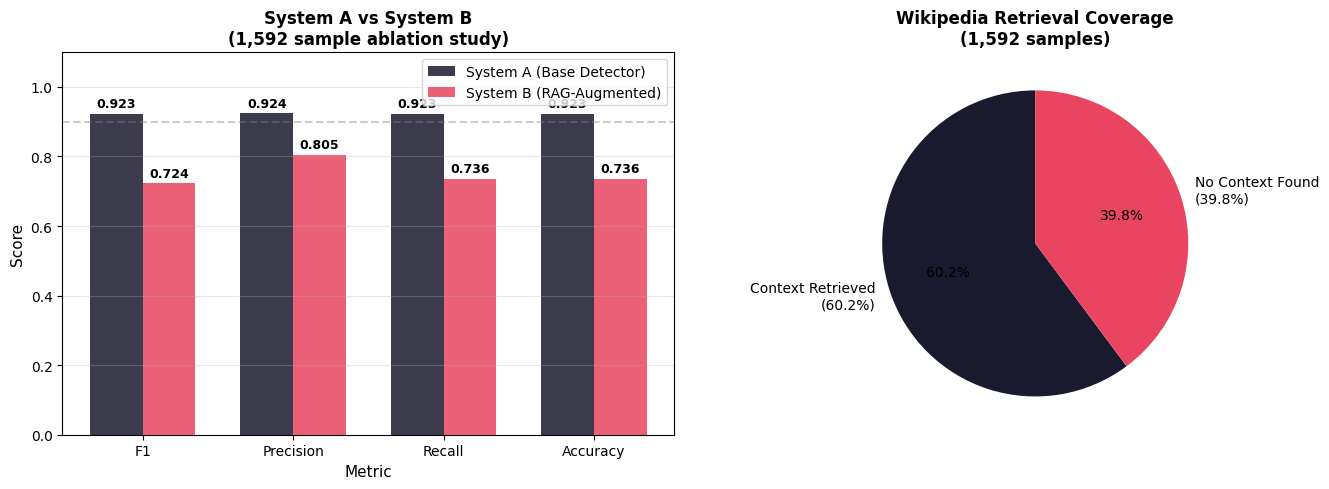

Saved to outputs/ablation_study_full.png


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting
metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
system_a = [f1_a, precision_a, recall_a, accuracy_a]
system_b = [f1_b, precision_b, recall_b, accuracy_b]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
metrics = ['F1', 'Precision', 'Recall', 'Accuracy']
system_a = [0.9234, 0.9236, 0.9234, 0.9234]
system_b = [0.7236, 0.8046, 0.7356, 0.7356]

x = np.arange(len(metrics))
width = 0.35

bars_a = axes[0].bar(x - width/2, system_a, width,
                     label='System A (Base Detector)',
                     color='#1a1a2e', alpha=0.85)
bars_b = axes[0].bar(x + width/2, system_b, width,
                     label='System B (RAG-Augmented)',
                     color='#e94560', alpha=0.85)

for bar in bars_a:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

for bar in bars_b:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

axes[0].set_xlabel('Metric', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('System A vs System B\n(1,592 sample ablation study)',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=10)
axes[0].axhline(y=0.9, color='grey', linestyle='--', alpha=0.4)
axes[0].grid(axis='y', alpha=0.3)

# Retrieval coverage pie chart
labels = ['Context Retrieved\n(60.2%)', 'No Context Found\n(39.8%)']
sizes = [958, 634]
colors = ['#1a1a2e', '#e94560']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Wikipedia Retrieval Coverage\n(1,592 samples)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/ablation_study_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/ablation_study_full.png")

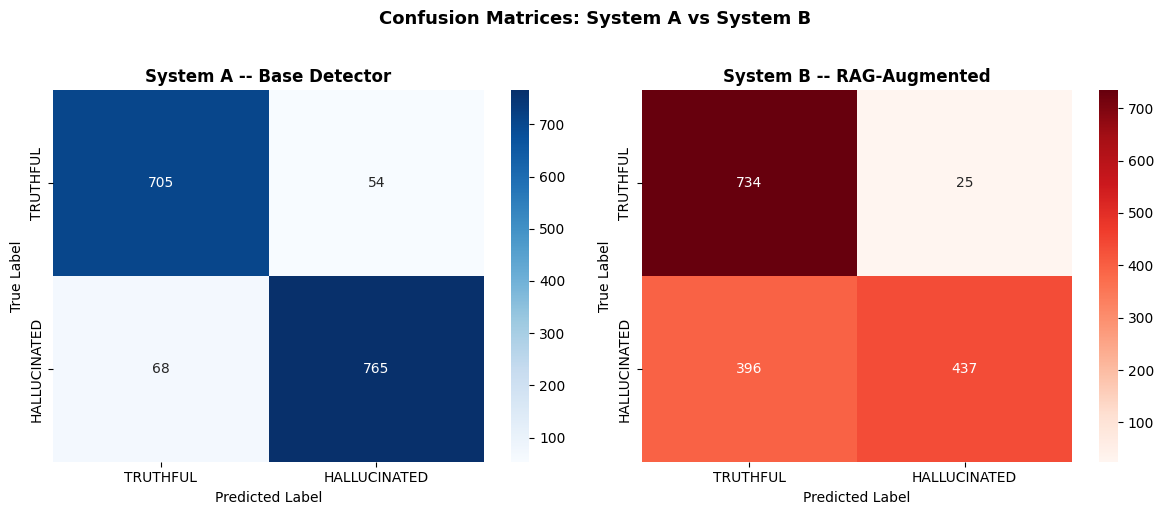

Saved to outputs/confusion_matrices_ablation.png


In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# System A confusion matrix
cm_a = confusion_matrix(true_labels, preds_a)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues',
            xticklabels=['TRUTHFUL', 'HALLUCINATED'],
            yticklabels=['TRUTHFUL', 'HALLUCINATED'],
            ax=axes[0])
axes[0].set_title('System A -- Base Detector', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# System B confusion matrix
cm_b = confusion_matrix(true_labels, preds_b)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Reds',
            xticklabels=['TRUTHFUL', 'HALLUCINATED'],
            yticklabels=['TRUTHFUL', 'HALLUCINATED'],
            ax=axes[1])
axes[1].set_title('System B -- RAG-Augmented', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices: System A vs System B',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/confusion_matrices_ablation.png")

In [11]:
# Find cases where System A was correct but System B was not
a_right_b_wrong = results_df[
    (results_df['pred_a'] == results_df['true_label']) &
    (results_df['pred_b'] != results_df['true_label'])
].reset_index(drop=True)

# Find cases where System B was correct but System A was not
b_right_a_wrong = results_df[
    (results_df['pred_b'] == results_df['true_label']) &
    (results_df['pred_a'] != results_df['true_label'])
].reset_index(drop=True)

# Find cases where both were wrong
both_wrong = results_df[
    (results_df['pred_a'] != results_df['true_label']) &
    (results_df['pred_b'] != results_df['true_label'])
].reset_index(drop=True)

print(f"System A correct, System B wrong: {len(a_right_b_wrong)} cases")
print(f"System B correct, System A wrong: {len(b_right_a_wrong)} cases")
print(f"Both wrong: {len(both_wrong)} cases")

print("\n=== CASES WHERE RAG HURT PERFORMANCE ===")
for i, row in a_right_b_wrong.iterrows():
    print(f"\nCase {i+1}:")
    print(f"Question: {row['question']}")
    print(f"Answer: {row['answer']}")
    print(f"True label: {'HALLUCINATED' if row['true_label'] == 1 else 'TRUTHFUL'}")
    print(f"System A: {row['verdict_a']}")
    print(f"System B: {row['verdict_b']}")
    print(f"Context used: {row['context'][:200] if row['context'] else 'None'}")
    print("---")

System A correct, System B wrong: 341 cases
System B correct, System A wrong: 42 cases
Both wrong: 80 cases

=== CASES WHERE RAG HURT PERFORMANCE ===

Case 1:
Question: What is the another name for the singer of Standing Hampton?
Answer: The singer of Standing Hampton is also known as The Red Rocker.
True label: HALLUCINATED
System A: HALLUCINATED
System B: TRUTHFUL
Context used: Hampton is a suburb of Greater London on the north bank of the River Thames, in the London Borough of Richmond upon Thames, England, and the historic county of Middlesex. Hampton is bounded by Bushy P
---

Case 2:
Question: In 2011, which of the nine official regions of England abolished the Blackburn with Darwen tPCT in April 2013?
Answer: The Midlands abolished Blackburn with Darwen tPCT.
True label: HALLUCINATED
System A: HALLUCINATED
System B: TRUTHFUL
Context used: Islam is the second-largest religion in the United Kingdom, with results from the 2021 Census recording just under four million Muslims, or 6.

In [16]:
a_right_b_wrong_full = results_df[
    (results_df['pred_a'] == results_df['true_label']) &
    (results_df['pred_b'] != results_df['true_label'])
]

b_right_a_wrong_full = results_df[
    (results_df['pred_b'] == results_df['true_label']) &
    (results_df['pred_a'] != results_df['true_label'])
]

print(f"System A correct, System B wrong: {len(a_right_b_wrong_full)}")
print(f"System B correct, System A wrong: {len(b_right_a_wrong_full)}")

System A correct, System B wrong: 341
System B correct, System A wrong: 42


## Error Analysis: Why RAG Hurts

System A was correct but System B was wrong in 341 cases out of 1,592.
System B was correct but System A was wrong in only 42 cases.

The ratio is 8:1 in favour of System A -- for every case where RAG helped,
it hurt in eight others.

Two distinct failure modes identified:

**Failure Mode 1 -- Irrelevant retrieval (majority of cases):**
The retriever returns context that is topically adjacent but factually
unrelated to the specific claim. With no contradiction present, the
model defaults to TRUTHFUL.

Examples: "All Germans are tall" retrieved a philosophy paper.
"Driving barefoot gets you arrested" retrieved a Mariah Carey article.

**Failure Mode 2 -- Relevant retrieval, vague hallucination:**
The retriever finds the correct article but the hallucinated answer
is vague enough that no explicit contradiction appears in the summary.

Example: "Born on a sunny day in August" retrieved the correct Abwehr
article but the vague claim found no contradiction.

**Implication:** Hallucination detection via RAG requires semantic
retrieval precision, not just topical relevance. A retriever that
returns the right article is not sufficient -- it must return the
specific passage that contradicts the claim. This is a fundamentally
harder retrieval problem than standard RAG applications.